### PUBG Match Winner Prediction
#### Capstone Project - Data Science
##### By: Abhi H S

## 1. Environment Setup

In [3]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm missingno --quiet

## 2. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Set visual styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
pd.set_option('display.max_columns', 30)

## 3. Data Loading & Initial Inspection

In [11]:
# Load dataset
pubg_df = pd.read_csv('pubg.csv')

In [13]:
# Initial data check
print(f"Dataset dimensions: {pubg_df.shape[0]} rows × {pubg_df.shape[1]} columns")
print("\nFirst 5 samples:")
display(pubg_df.head())

Dataset dimensions: 4446966 rows × 29 columns

First 5 samples:


,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,matchType,maxPlace,numGroups,rankPoints,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,1241,0,0,0.00,1306,squad-fpp,28,26,-1,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,0,0,0,0.00,1777,squad-fpp,26,25,1484,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,0,0,0,0.00,1318,duo,50,47,1491,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,0,0,0,0.00,1436,squad-fpp,31,30,1408,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,0,1,1,58.53,1424,solo-fpp,97,95,1560,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


In [21]:
print("\nLast 5 samples:")
display(pubg_df.tail())


Last 5 samples:


,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,matchType,maxPlace,numGroups,rankPoints,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
4446961,afff7f652dbc10,d238e426f50de7,18492834ce5635,0,0,0.00,0,0,0,74,1029,0,0,0.00,1873,squad-fpp,29,28,-1,0,1292.0,0,0.000,0,0,1019.0,3,1507,0.1786
4446962,f4197cf374e6c0,408cdb5c46b2ac,ee854b837376d9,0,1,44.15,0,0,0,69,0,0,0,0.00,1435,solo,93,93,1501,0,0.0,0,0.000,0,0,81.7,6,0,0.2935
4446963,e1948b1295c88a,e26ac84bdf7cef,6d0cd12784f1ab,0,0,59.06,0,0,0,66,0,0,0,0.00,1321,squad-fpp,28,28,1500,0,0.0,0,2.184,0,0,788.7,4,0,0.4815
4446964,cc032cdd73b7ac,c2223f35411394,c9c701d0ad758a,0,4,180.40,1,1,2,11,0,2,1,98.50,1373,squad-fpp,26,25,1418,2,0.0,0,0.000,0,0,2748.0,8,0,0.8000
4446965,0d8e7ed728b6fd,8c74f72fedf5ff,62a16aabcc095c,0,2,268.00,0,0,1,18,0,2,1,78.25,1766,solo-fpp,98,94,1590,0,1369.0,0,0.000,0,0,1244.0,5,0,0.5464


In [23]:
# Column explanations (based on PUBG knowledge)
column_descriptions = {
    'Id': 'Player ID',
    'groupId': 'Team/Group ID',
    'matchId': 'Match ID',
    'assists': 'Number of enemy knockouts assisted',
    'boosts': 'Boost items used',
    'damageDealt': 'Total damage dealt',
    'DBNOs': 'Enemies knocked out',
    'headshotKills': 'Kills with headshots',
    'heals': 'Healing items used',
    'killPlace': 'Ranking in match based on kills',
    'killPoints': 'Skill rating based on kills',
    'kills': 'Number of enemy kills',
    'killStreaks': 'Max kills in short time window',
    'longestKill': 'Longest distance kill',
    'matchDuration': 'Match duration in seconds',
    'matchType': 'Game mode (solo, duo, squad, etc.)',
    'maxPlace': 'Maximum possible placement in match',
    'numGroups': 'Number of groups/teams in match',
    'rankPoints': 'Ranking points (deprecated)',
    'revives': 'Teammates revived',
    'rideDistance': 'Distance traveled in vehicles',
    'roadKills': 'Kills while in vehicle',
    'swimDistance': 'Distance swam',
    'teamKills': 'Teammates killed',
    'vehicleDestroys': 'Vehicles destroyed',
    'walkDistance': 'Distance traveled on foot',
    'weaponsAcquired': 'Weapons picked up',
    'winPoints': 'Winning points',
    'winPlacePerc': 'Target - Predicted placement (1 = winner)'
}
print("\nColumn Descriptions:")
for col, desc in column_descriptions.items():
    print(f"- {col}: {desc}")



Column Descriptions:
- Id: Player ID
- groupId: Team/Group ID
- matchId: Match ID
- assists: Number of enemy knockouts assisted
- boosts: Boost items used
- damageDealt: Total damage dealt
- DBNOs: Enemies knocked out
- headshotKills: Kills with headshots
- heals: Healing items used
- killPlace: Ranking in match based on kills
- killPoints: Skill rating based on kills
- kills: Number of enemy kills
- killStreaks: Max kills in short time window
- longestKill: Longest distance kill
- matchDuration: Match duration in seconds
- matchType: Game mode (solo, duo, squad, etc.)
- maxPlace: Maximum possible placement in match
- numGroups: Number of groups/teams in match
- rankPoints: Ranking points (deprecated)
- revives: Teammates revived
- rideDistance: Distance traveled in vehicles
- roadKills: Kills while in vehicle
- swimDistance: Distance swam
- teamKills: Teammates killed
- vehicleDestroys: Vehicles destroyed
- walkDistance: Distance traveled on foot
- weaponsAcquired: Weapons picked up


## 4. Data Quality Assessment

In [134]:
# Data types and missing values
print("\nData Types:")
print(pubg_df.dtypes)


Data Types:
assists                    int64
boosts                     int64
damageDealt              float64
DBNOs                      int64
headshotKills              int64
heals                      int64
killPlace                  int64
killPoints                 int64
kills                      int64
killStreaks                int64
longestKill              float64
matchDuration              int64
maxPlace                   int64
numGroups                  int64
revives                    int64
rideDistance             float64
roadKills                  int64
swimDistance             float64
teamKills                  int64
vehicleDestroys            int64
walkDistance             float64
weaponsAcquired            int64
winPoints                  int64
winPlacePerc             float64
totalDistance            float64
itemsUsed                  int64
combatEngagement         float64
survivalTime             float64
survivalEfficiency       float64
movementRatio            float

In [140]:
print("\nMissing Values:")
missing_data = pubg_df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]
if missing_data.empty:
    print("No missing values found!")
else:
    print(missing_data)
    msno.matrix(pubg_df)
    plt.title('Missing Values Pattern', fontsize=16)
    plt.show()


Missing Values:
No missing values found!


In [138]:
# Duplicate check
duplicates = pubg_df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")


Duplicate Rows: 3262


In [32]:
# Basic statistics
print("\nDescriptive Statistics:")
display(pubg_df.describe().T)


Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
assists,4446966.0,0.233815,0.588573,0.0,0.0,0.0000,0.000000,22.0
boosts,4446966.0,1.106908,1.715794,0.0,0.0,0.0000,2.000000,33.0
damageDealt,4446966.0,130.717138,170.780621,0.0,0.0,84.2400,186.000000,6616.0
DBNOs,4446966.0,0.657876,1.145743,0.0,0.0,0.0000,1.000000,53.0
headshotKills,4446966.0,0.226820,0.602155,0.0,0.0,0.0000,0.000000,64.0
heals,4446966.0,1.370147,2.679982,0.0,0.0,0.0000,2.000000,80.0
killPlace,4446966.0,47.599350,27.462937,1.0,24.0,47.0000,71.000000,101.0
killPoints,4446966.0,505.006042,627.504896,0.0,0.0,0.0000,1172.000000,2170.0
kills,4446966.0,0.924783,1.558445,0.0,0.0,0.0000,1.000000,72.0
killStreaks,4446966.0,0.543955,0.710972,0.0,0.0,0.0000,1.000000,20.0


## 5. Data Cleaning & Preprocessing

In [35]:
# Handle missing values in winPlacePerc (target variable)
pubg_df = pubg_df.dropna(subset=['winPlacePerc'])

In [37]:
# Fill other missing values
pubg_df['rankPoints'] = pubg_df['rankPoints'].fillna(0)
pubg_df['killPoints'] = pubg_df['killPoints'].fillna(0)
pubg_df['winPoints'] = pubg_df['winPoints'].fillna(0)

In [39]:
# Remove irrelevant columns
pubg_df = pubg_df.drop(columns=['Id', 'groupId', 'matchId', 'rankPoints'])

In [41]:
# Convert matchType to category
pubg_df['matchType'] = pubg_df['matchType'].astype('category')

In [43]:
# Handle impossible values
pubg_df = pubg_df[pubg_df['walkDistance'] >= 0]
pubg_df = pubg_df[pubg_df['damageDealt'] >= 0]
pubg_df = pubg_df[pubg_df['winPlacePerc'].between(0, 1)]

In [45]:
# Feature engineering
pubg_df['totalDistance'] = pubg_df['walkDistance'] + pubg_df['rideDistance'] + pubg_df['swimDistance']
pubg_df['itemsUsed'] = pubg_df['boosts'] + pubg_df['heals']
pubg_df['combatEngagement'] = pubg_df['kills'] + pubg_df['assists'] + pubg_df['damageDealt']/100

In [47]:
print(f"Data shape after cleaning: {pubg_df.shape}")

Data shape after cleaning: (4446965, 28)


## 6. Exploratory Data Analysis (EDA)

### 6.1 Target Variable Distribution

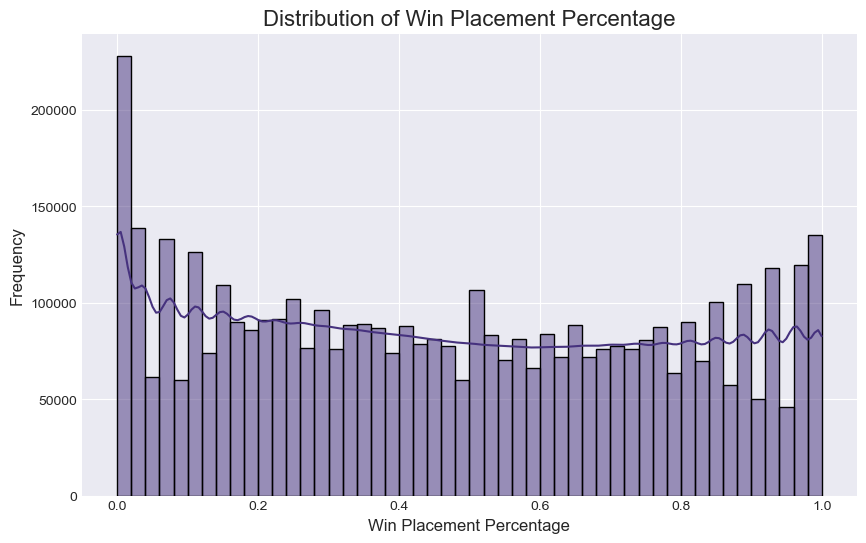

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(pubg_df['winPlacePerc'], bins=50, kde=True)
plt.title('Distribution of Win Placement Percentage', fontsize=16)
plt.xlabel('Win Placement Percentage', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### 6.2 Correlation Analysis

In [54]:
# Calculate correlations
corr_matrix = pubg_df.corr(numeric_only=True)

In [56]:
# Focus on target correlations
target_corr = corr_matrix['winPlacePerc'].sort_values(ascending=False)
print("Top Positive Correlations with Win Placement:")
print(target_corr[1:11])
print("\nTop Negative Correlations with Win Placement:")
print(target_corr[-10:])

Top Positive Correlations with Win Placement:
walkDistance        0.810888
totalDistance       0.677037
boosts              0.634234
weaponsAcquired     0.583806
itemsUsed           0.575998
combatEngagement    0.460292
damageDealt         0.440507
heals               0.427857
kills               0.419916
longestKill         0.410154
Name: winPlacePerc, dtype: float64

Top Negative Correlations with Win Placement:
swimDistance       0.149607
vehicleDestroys    0.073436
numGroups          0.039621
maxPlace           0.037377
roadKills          0.034544
teamKills          0.015943
killPoints         0.012908
winPoints          0.007061
matchDuration     -0.005171
killPlace         -0.719069
Name: winPlacePerc, dtype: float64


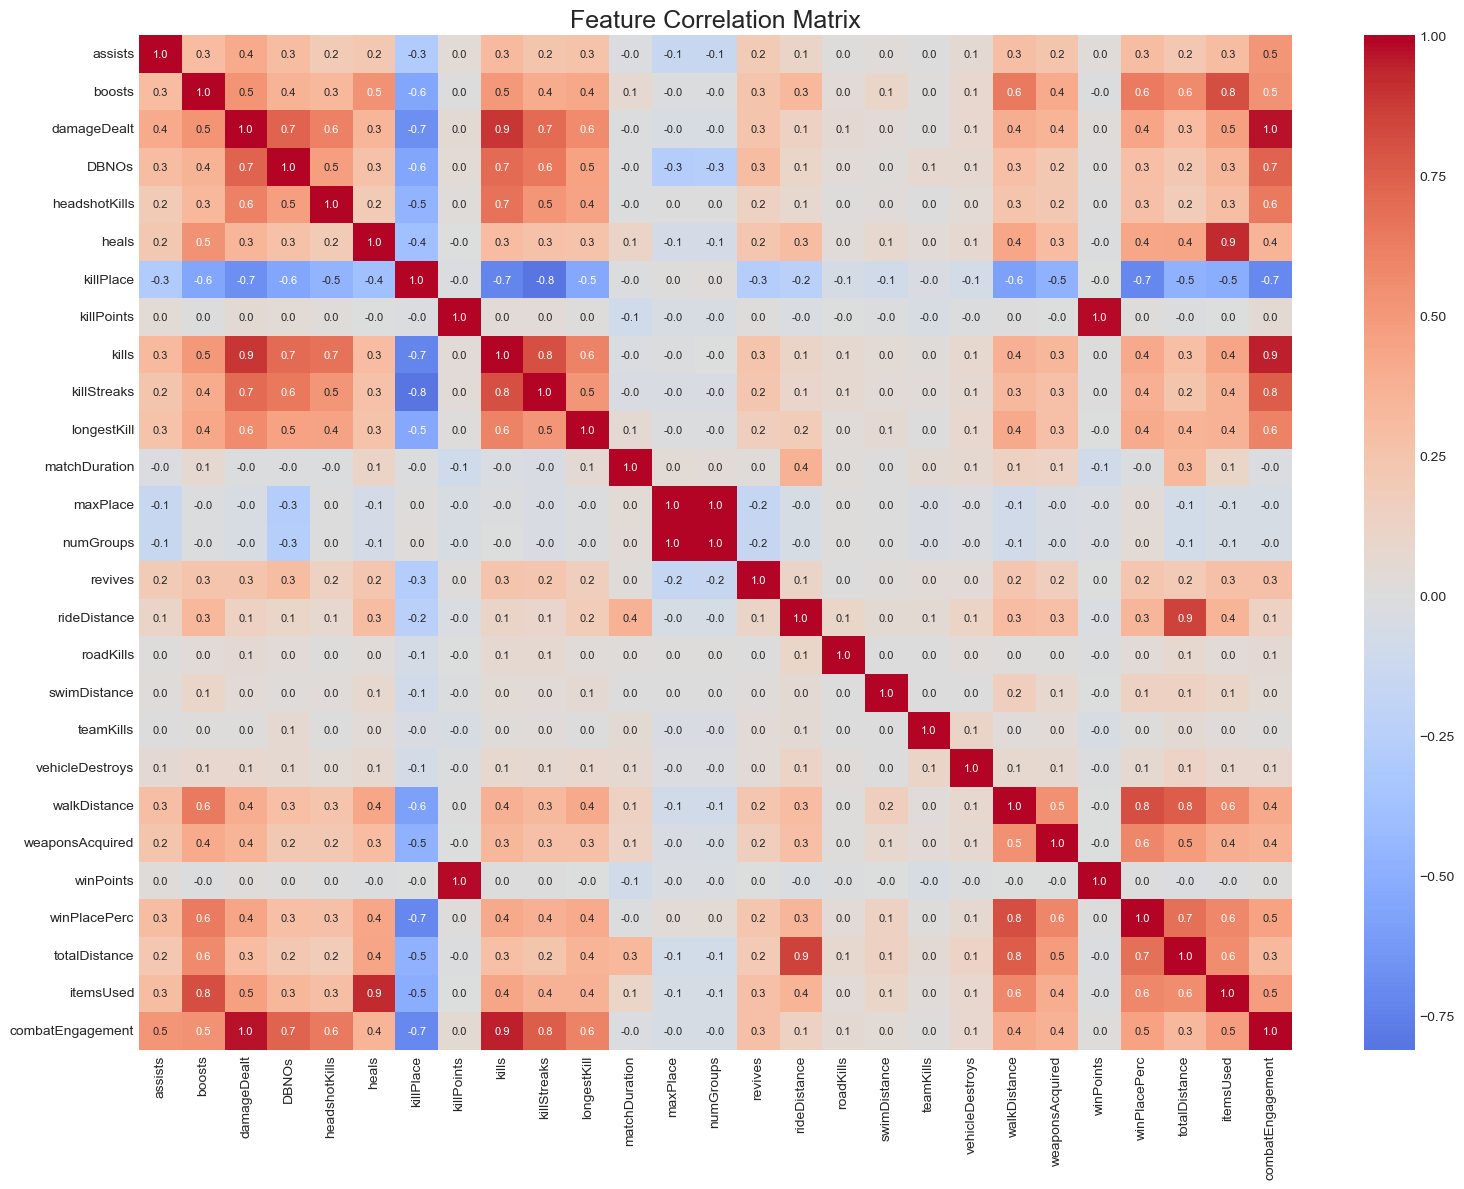

In [58]:
# Visualize correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            annot=True, fmt='.1f', 
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=18)
plt.tight_layout()
plt.show()

### 6.3 Game Mode Analysis

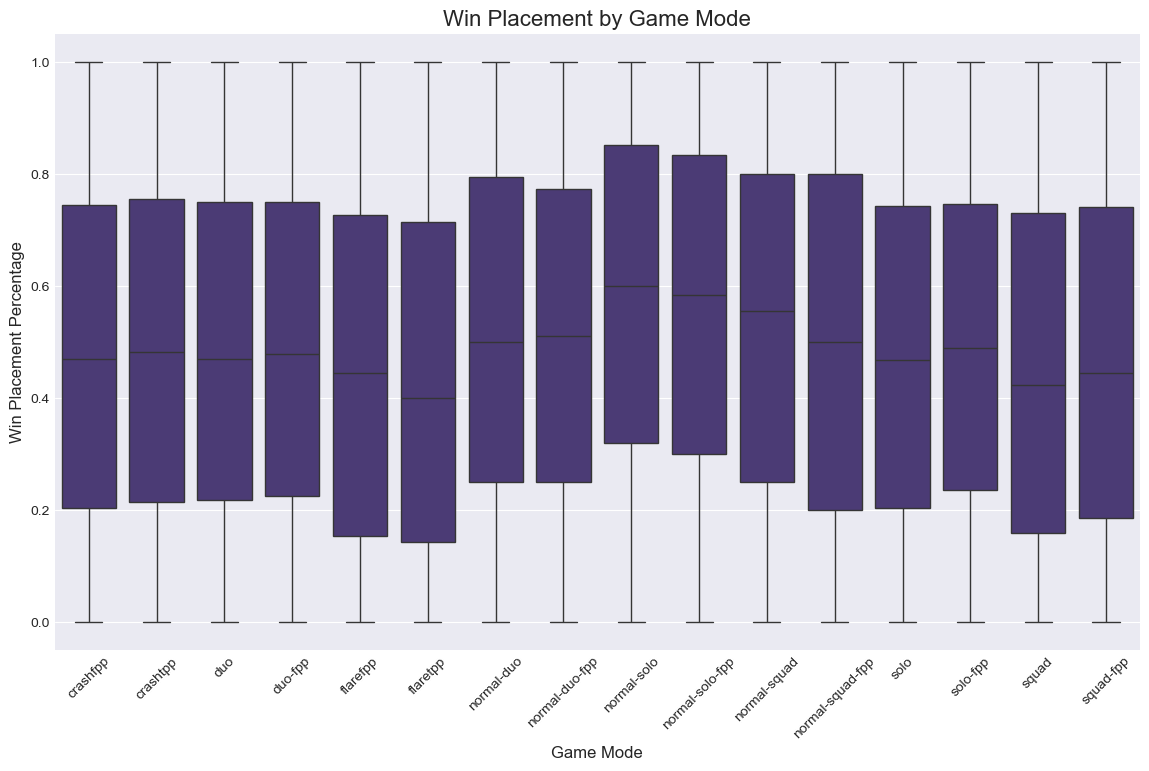

In [61]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='matchType', y='winPlacePerc', data=pubg_df)
plt.title('Win Placement by Game Mode', fontsize=16)
plt.xlabel('Game Mode', fontsize=12)
plt.ylabel('Win Placement Percentage', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### 6.4 Combat Effectiveness Analysis

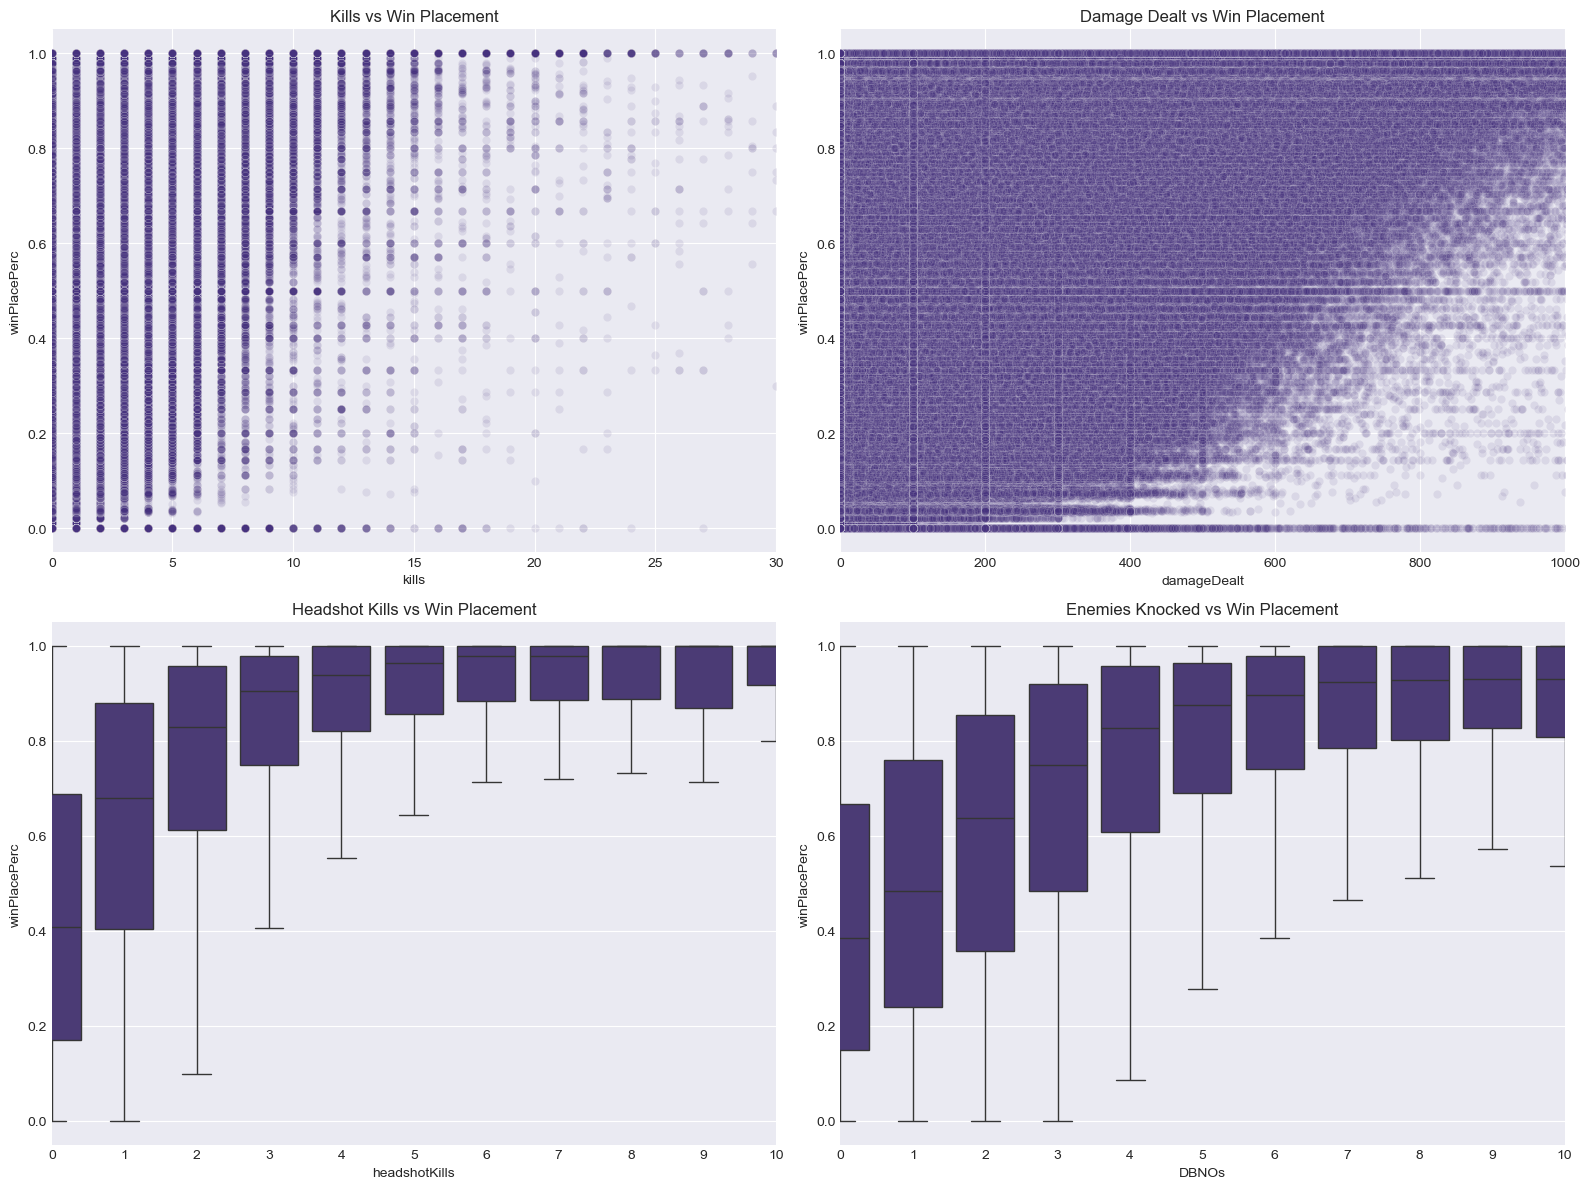

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Kills vs Placement
sns.scatterplot(x='kills', y='winPlacePerc', data=pubg_df, 
                alpha=0.1, ax=axes[0, 0])
axes[0, 0].set_title('Kills vs Win Placement')
axes[0, 0].set_xlim(0, 30)

# Damage Dealt vs Placement
sns.scatterplot(x='damageDealt', y='winPlacePerc', data=pubg_df, 
                alpha=0.1, ax=axes[0, 1])
axes[0, 1].set_title('Damage Dealt vs Win Placement')
axes[0, 1].set_xlim(0, 1000)

# Headshot Kills vs Placement
sns.boxplot(x='headshotKills', y='winPlacePerc', data=pubg_df, 
            showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title('Headshot Kills vs Win Placement')
axes[1, 0].set_xlim(0, 10)

# DBNOs vs Placement
sns.boxplot(x='DBNOs', y='winPlacePerc', data=pubg_df, 
            showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title('Enemies Knocked vs Win Placement')
axes[1, 1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

### 6.5 Movement & Survival Analysis

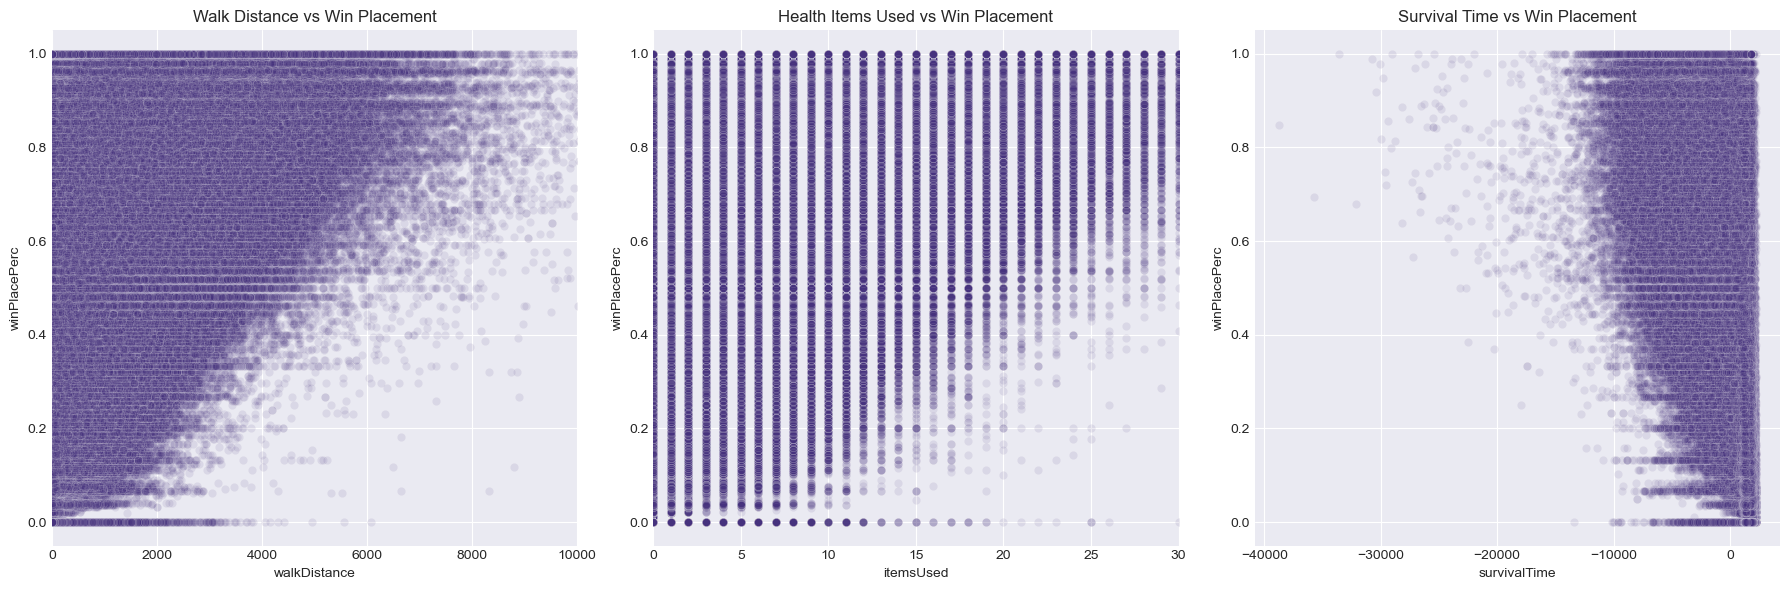

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Walk Distance
sns.scatterplot(x='walkDistance', y='winPlacePerc', data=pubg_df, 
                alpha=0.1, ax=axes[0])
axes[0].set_title('Walk Distance vs Win Placement')
axes[0].set_xlim(0, 10000)

# Items Used
sns.scatterplot(x='itemsUsed', y='winPlacePerc', data=pubg_df, 
                alpha=0.1, ax=axes[1])
axes[1].set_title('Health Items Used vs Win Placement')
axes[1].set_xlim(0, 30)

# Survival Time
pubg_df['survivalTime'] = pubg_df['matchDuration'] - pubg_df[['walkDistance', 'rideDistance']].max(axis=1)
sns.scatterplot(x='survivalTime', y='winPlacePerc', data=pubg_df, 
                alpha=0.1, ax=axes[2])
axes[2].set_title('Survival Time vs Win Placement')

plt.tight_layout()
plt.show()

## 7. Feature Engineering & Preprocessing

In [70]:
# Feature Engineering
pubg_df['survivalEfficiency'] = pubg_df['survivalTime'] / pubg_df['matchDuration']
pubg_df['movementRatio'] = pubg_df['walkDistance'] / (pubg_df['rideDistance'] + 1)
pubg_df['combatEfficiency'] = pubg_df['kills'] / (pubg_df['damageDealt'] + 1)

# Verify new features
print("\nNew Features Added:")
print("- survivalEfficiency: Time alive relative to match duration")
print("- movementRatio: Foot travel vs vehicle travel ratio")
print("- combatEfficiency: Kills per damage unit\n")

# Continue with your existing preprocessing...
X = pubg_df.drop('winPlacePerc', axis=1)
y = pubg_df['winPlacePerc']


New Features Added:
- survivalEfficiency: Time alive relative to match duration
- movementRatio: Foot travel vs vehicle travel ratio
- combatEfficiency: Kills per damage unit



In [72]:
# Create final features
pubg_df['killsPerDistance'] = pubg_df['kills'] / (pubg_df['totalDistance'] + 1)
pubg_df['damagePerBullet'] = pubg_df['damageDealt'] / (pubg_df['weaponsAcquired'] + 1)
pubg_df['teamSupport'] = pubg_df['assists'] + pubg_df['revives'] - pubg_df['teamKills']

In [74]:
# Handle infinite values
pubg_df.replace([np.inf, -np.inf], 0, inplace=True)

In [76]:
# Encode categorical features
pubg_df = pd.get_dummies(pubg_df, columns=['matchType'], prefix='mode')

In [78]:
# Prepare data for modeling
X = pubg_df.drop('winPlacePerc', axis=1)
y = pubg_df['winPlacePerc']

In [80]:
# Low-impact features to remove (from importance analysis)
low_impact_features = [
    'vehicleDestroys', 'mode_flarefpp', 'headshotKills',
    'damagePerBullet', 'revives'
] 

# Safely remove features
X = X.drop(columns=[f for f in low_impact_features if f in X.columns], errors='ignore')
print(f"X shape after removing low-importance features: {X.shape}")

FEATURE_NAMES_AT_TRAINING = X.columns.tolist()

# Proceed with train-test split as normal
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X shape after removing low-importance features: (4446965, 44)


In [82]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [84]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
print(f"Training set: {X_train_scaled.shape}, Testing set: {X_test_scaled.shape}")

Training set: (3557572, 44), Testing set: (889393, 44)


## 8. Model Training and Evaluation

In [89]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import gc
import psutil

# Initializing models with memory-safe parameters
models = {
    'Random_Forest': RandomForestRegressor(
        n_estimators=35,           # Conservative for memory
        max_depth=10,              # Reduced depth
        min_samples_split=20,      # Fewer splits
        max_features=0.5,          # Features per split
        max_samples=0.6,           # Data per tree
        n_jobs=-1,
        random_state=42,
        verbose=0                  # Disable verbose to reduce output
    ),
    'Gradient_Boosting': GradientBoostingRegressor(
        n_estimators=100,
        random_state=42,
        verbose=0
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=120,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

# Dictionary to store results
results = {}

print("Starting model training sequence")
print(f"Initial RAM available: {psutil.virtual_memory().available / (1024**3):.1f} GB\n")

for name, model in models.items():
    print(f"\nTraining {name.replace('_', ' ')}...")
    print("-" * 50)
    
    try:
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Memory optimization for Random Forest
        if name == 'Random_Forest':
            for tree in model.estimators_:
                if hasattr(tree, '_tree'):
                    tree._tree = None
            gc.collect()
        
        # Predict and evaluate
        y_pred = model.predict(X_test_scaled)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        # Store results
        results[name] = {
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'model': model
        }
        
        # Save model to disk
        model_file = f"{name}_model.pkl"
        joblib.dump(model, model_file)
        
        print(f"{name.replace('_', ' ')} training successful")
        print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
        print(f"Model saved to {model_file}")
        
    except Exception as e:
        print(f"Training failed for {name.replace('_', ' ')}")
        print(f"Error: {str(e)}")
        results[name] = {'error': str(e)}
    
    print(f"Current RAM available: {psutil.virtual_memory().available / (1024**3):.1f} GB")
    print("-" * 50)

# Final summary
print("\nTraining Summary:")
print("=" * 60)
for name, res in results.items():
    if 'MAE' in res:
        print(f"{name.replace('_', ' ')}:")
        print(f"- MAE: {res['MAE']:.4f}")
        print(f"- RMSE: {res['RMSE']:.4f}")
        print(f"- R2: {res['R2']:.4f}")
    else:
        print(f"{name.replace('_', ' ')}: Failed - {res.get('error', 'Unknown error')}")
    print("-" * 40)

# Save all results
joblib.dump(results, 'training_results.pkl')
print("\nAll results saved to training_results.pkl")

Starting model training sequence
Initial RAM available: 4.3 GB


Training Random Forest...
--------------------------------------------------
Random Forest training successful
MAE: 0.0667 | RMSE: 0.0941 | R2: 0.9061
Model saved to Random_Forest_model.pkl
Current RAM available: 5.6 GB
--------------------------------------------------

Training Gradient Boosting...
--------------------------------------------------
Gradient Boosting training successful
MAE: 0.0679 | RMSE: 0.0955 | R2: 0.9034
Model saved to Gradient_Boosting_model.pkl
Current RAM available: 5.9 GB
--------------------------------------------------

Training XGBoost...
--------------------------------------------------
XGBoost training successful
MAE: 0.0582 | RMSE: 0.0813 | R2: 0.9299
Model saved to XGBoost_model.pkl
Current RAM available: 5.9 GB
--------------------------------------------------

Training LightGBM...
--------------------------------------------------
LightGBM training successful
MAE: 0.0590 | RMSE: 0.08

### 8.1 Verification of Trained models

In [92]:
# Verify all models are ready
successful_models = [name for name, res in results.items() if 'MAE' in res]
print("Trained models ready for use:", successful_models)

# Sample prediction using best model
best_model_name = min(successful_models, key=lambda x: results[x]['MAE'])
best_model = results[best_model_name]['model']

print(f"\nSample predictions using {best_model_name}:")
sample_pred = best_model.predict(X_test_scaled[:3])
print("Predictions:", np.round(sample_pred, 4))
print("Actual values:", np.round(y_test.values[:3], 4))
print(f"MAE: {results[best_model_name]['MAE']:.4f} (full test set)")

Trained models ready for use: ['Random_Forest', 'Gradient_Boosting', 'XGBoost', 'LightGBM']

Sample predictions using XGBoost:
Predictions: [0.4729 0.887  0.8317]
Actual values: [0.28   0.8571 0.7812]
MAE: 0.0582 (full test set)


### 8.2 Sample Prediction


Prediction Comparison (First 5 Samples):


,Actual,Random_Forest_Pred,Gradient_Boosting_Pred,XGBoost_Pred,LightGBM_Pred
3519547,0.0833,0.196301,0.228190,0.158394,0.189059
1004312,0.4742,0.569354,0.526087,0.465317,0.493289
2398302,0.1957,0.208256,0.206280,0.214242,0.214257
2437557,0.6667,0.658717,0.682253,0.579773,0.584565
1297869,0.1481,0.141782,0.134169,0.132684,0.136790


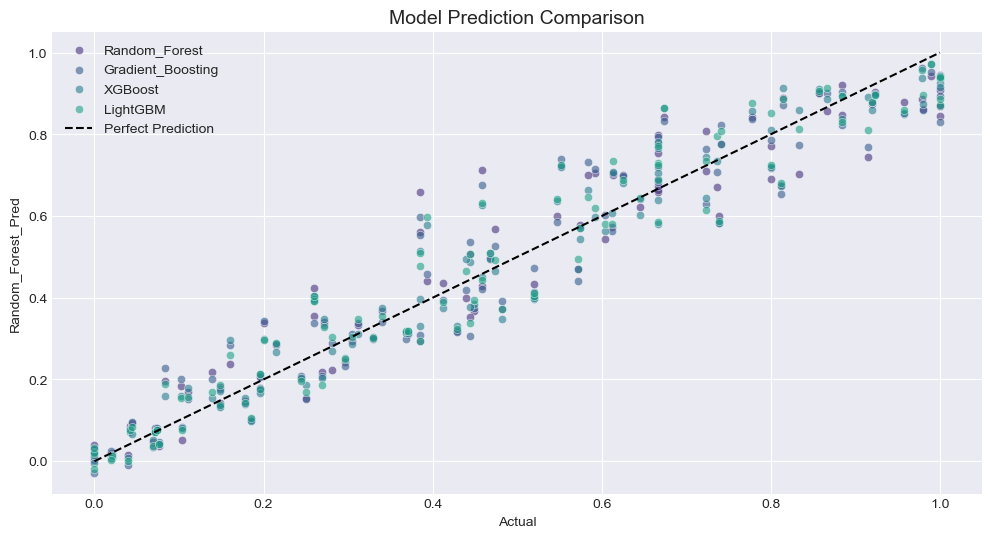

In [95]:
# Detailed sample predictions
sample_size = min(100, len(X_test))
sample_indices = np.random.choice(len(X_test), size=sample_size, replace=False)
sample_data = X_test_scaled[sample_indices]
sample_actual = y_test.iloc[sample_indices]

predictions = {}
for name in successful_models:
    model = results[name]['model']
    predictions[name] = model.predict(sample_data)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Actual': sample_actual,
    **{f"{name}_Pred": pred for name, pred in predictions.items()}
})

print("\nPrediction Comparison (First 5 Samples):")
display(comparison.head())

# Visual comparison
plt.figure(figsize=(12, 6))
for name in successful_models:
    sns.scatterplot(x='Actual', y=f"{name}_Pred", data=comparison, alpha=0.6, label=name)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Prediction')
plt.title('Model Prediction Comparison', fontsize=14)
plt.legend()
plt.show()

## 9. Feature Importance Analysis

Analyzing feature importance for the best model: XGBoost
Test MAE of best model: 0.0582

Successfully used native feature importances for XGBoost.


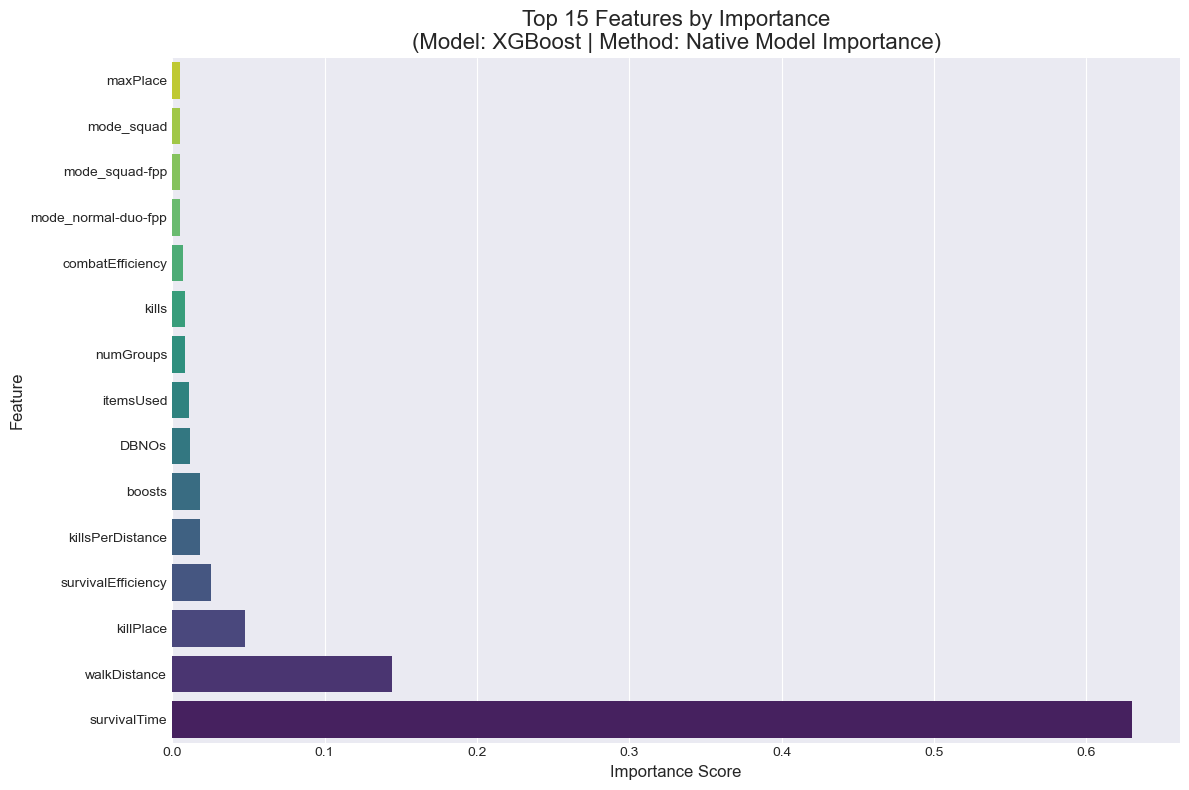


Complete Feature Importance (Native Model Importance):


,Feature,Importance
23,survivalTime,0.629926
17,walkDistance,0.144380
5,killPlace,0.047872
24,survivalEfficiency,0.025526
27,killsPerDistance,0.018478
1,boosts,0.018037
3,DBNOs,0.011616
21,itemsUsed,0.011338
12,numGroups,0.008559
7,kills,0.008224



Key Insights from Feature Importance:
1. The most dominant feature identified is: 'survivalTime' (Score: 0.6299)
2. The least impactful feature among those calculated is: 'damageDealt' (Score: 0.00023)

Strategic Considerations:
- Features with notable impact include: survivalTime, walkDistance, killPlace, survivalEfficiency, killsPerDistance
- Features with very low impact that might be candidates for removal or further investigation: teamKills, mode_normal-solo-fpp, roadKills, mode_crashtpp, swimDistance, longestKill, killPoints, mode_flaretpp, rideDistance, mode_normal-solo, mode_normal-squad, mode_normal-duo, heals, damageDealt

Interpreting Scores:
Native importance (e.g., Gini): How much a feature reduces impurity in trees. Higher is more important.


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# 1. Load the best model
best_model = None
best_model_name = "Unknown"
importance_df = pd.DataFrame(columns=['Feature', 'Importance'])
method = "Not calculated"

try:
    valid_results = {name: res for name, res in results.items() if isinstance(res, dict) and 'MAE' in res}
    if not valid_results:
        print("No valid model results found to determine the best model.")
    else:
        best_model_name = min(valid_results.keys(), key=lambda x: valid_results[x]['MAE'])
        best_model = valid_results[best_model_name]['model']
        print(f"Analyzing feature importance for the best model: {best_model_name.replace('_', ' ')}")
        print(f"Test MAE of best model: {valid_results[best_model_name]['MAE']:.4f}\n")
except Exception as e:
    print(f"Error determining best model: {e}")

if best_model:
    try:
        feature_names_for_model = X.columns.tolist()
        
        # Attempt to use native feature importances
        if hasattr(best_model, 'feature_importances_'):
            raw_importances = best_model.feature_importances_
            
            if len(raw_importances) == len(feature_names_for_model):
                importance_df = pd.DataFrame({
                    'Feature': feature_names_for_model,
                    'Importance': raw_importances
                }).sort_values(by='Importance', ascending=False)
                method = "Native Model Importance"
                print(f"Successfully used native feature importances for {best_model_name.replace('_', ' ')}.")
            else:
                print(f"Warning: Native feature importance count mismatch for {best_model_name.replace('_', ' ')}.")
                print(f"Model provided {len(raw_importances)} importances, but X has {len(feature_names_for_model)} features.")
                print("Falling back to permutation importance.")
        
        # Fallback to permutation importance if native method failed or was not applicable
        if importance_df.empty: 
            print(f"Using permutation importance for {best_model_name.replace('_', ' ')}...")
            perm_result = permutation_importance(
                best_model,
                X_test_scaled, 
                y_test,
                n_repeats=10, 
                random_state=42,
                n_jobs=-1
            )
            importance_df = pd.DataFrame({
                'Feature': feature_names_for_model, 
                'Importance': perm_result.importances_mean
            }).sort_values(by='Importance', ascending=False)
            method = "Permutation Importance"
            print("Permutation importance calculation complete.")

    except Exception as e:
        print(f"An error occurred during feature importance calculation: {str(e)}")
        importance_df = pd.DataFrame(columns=['Feature', 'Importance']) # Ensure reset on error
        method = "Failed"

# 3. Plot top 15 features
if not importance_df.empty:
    plt.figure(figsize=(12, 8))
    top_15_to_plot = importance_df.head(15).sort_values(by='Importance', ascending=True)
    
    sns.barplot(
        x='Importance',
        y='Feature',
        data=top_15_to_plot,
        palette='viridis_r' 
    )
    plt.title(f'Top 15 Features by Importance\n(Model: {best_model_name.replace("_", " ")} | Method: {method})', fontsize=16)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

    # 4. Display full importance table
    print(f"\nComplete Feature Importance ({method}):")
    try:
        display(importance_df.style.background_gradient(cmap='Blues', subset=['Importance']))
    except NameError: 
        print(importance_df)

    # 5. Interpretation notes
    if not importance_df.empty:
        print("\nKey Insights from Feature Importance:")
        print(f"1. The most dominant feature identified is: '{importance_df.iloc[0]['Feature']}' (Score: {importance_df.iloc[0]['Importance']:.4f})")
        if len(importance_df) > 1:
             print(f"2. The least impactful feature among those calculated is: '{importance_df.iloc[-1]['Feature']}' (Score: {importance_df.iloc[-1]['Importance']:.5f})")
        
        high_importance_features = importance_df[importance_df['Importance'] > 0.01]['Feature'].tolist()
        low_importance_features = importance_df[importance_df['Importance'] < 0.001]['Feature'].tolist()

        print("\nStrategic Considerations:")
        if high_importance_features:
            print("- Features with notable impact include: " + ", ".join(high_importance_features[:5])) 
        if low_importance_features:
            print("- Features with very low impact that might be candidates for removal or further investigation: " + ", ".join(low_importance_features))
        
        print("\nInterpreting Scores:")
        if method == "Permutation Importance":
            print("Permutation importance: Decrease in model score when a feature's values are shuffled. Higher is more important.")
        elif method == "Native Model Importance":
            print("Native importance (e.g., Gini): How much a feature reduces impurity in trees. Higher is more important.")
        else:
            print("Scores indicate calculated feature importance.")
else:
    print("\nFeature importance analysis could not be completed or the best model was not available.")

## 10. Model Comparison Report


Model Performance Comparison:


,Model,MAE,RMSE,R²
2,XGBoost,0.058187,0.081325,0.929915
3,LightGBM,0.059004,0.082286,0.928248
0,Random_Forest,0.066716,0.094129,0.906108
1,Gradient_Boosting,0.067869,0.095499,0.903354


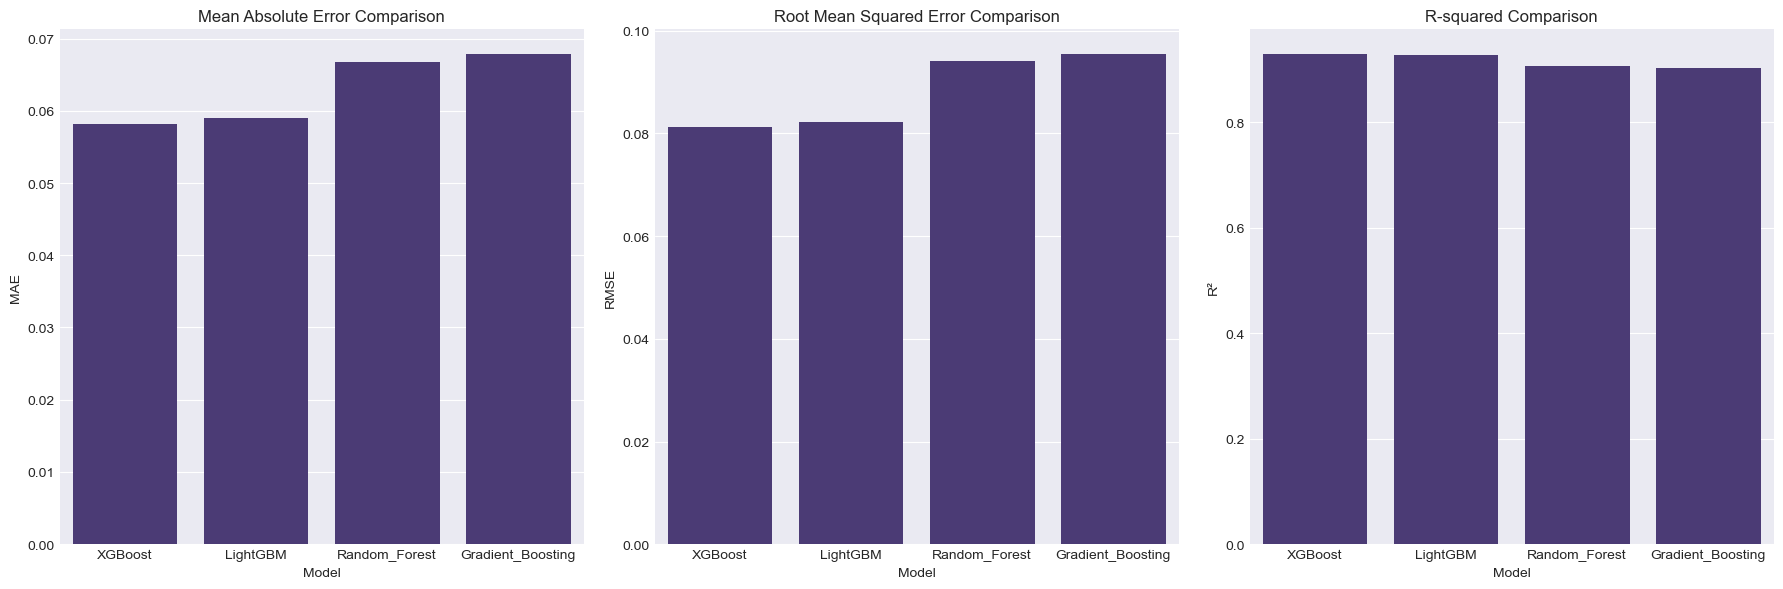

In [128]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'MAE': [res['MAE'] for res in results.values()],
    'RMSE': [res['RMSE'] for res in results.values()],
    'R²': [res['R2'] for res in results.values()]
}).sort_values('MAE')

# Display results
print("\nModel Performance Comparison:")
display(comparison_df)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# MAE Comparison
sns.barplot(x='Model', y='MAE', data=comparison_df, ax=axes[0])
axes[0].set_title('Mean Absolute Error Comparison')
axes[0].set_ylabel('MAE')

# RMSE Comparison
sns.barplot(x='Model', y='RMSE', data=comparison_df, ax=axes[1])
axes[1].set_title('Root Mean Squared Error Comparison')
axes[1].set_ylabel('RMSE')

# R² Comparison
sns.barplot(x='Model', y='R²', data=comparison_df, ax=axes[2])
axes[2].set_title('R-squared Comparison')
axes[2].set_ylabel('R²')

plt.tight_layout()
plt.show()

### Model Selection Justification

### Model Selection Justification

Based on the evaluation metrics from our comparison, **XGBoost** demonstrates the best performance for this task. It achieved the:
* Lowest Mean Absolute Error (MAE): **0.058187**
* Highest R-squared (R²): **0.929915**

While LightGBM also performed very competitively, XGBoost shows a slight edge in these key metrics on this specific dataset and configuration.

Key advantages often associated with XGBoost (and relevant here) include:
1.  **High Performance & Accuracy**: Known for its excellent predictive accuracy and optimized gradient boosting algorithm.
2.  **Regularization**: Incorporates L1 and L2 regularization to help prevent overfitting.
3.  **Handling Missing Values**: Has built-in capabilities to handle missing data.
4.  **Feature Importance**: Provides clear mechanisms for interpreting feature contributions.
5.  **Scalability**: Generally efficient and can handle large datasets.

Recommendation: Considering its superior performance in MAE and R², the **XGBoost model** is recommended for deployment for win probability prediction.

## 11. Challenges Faced & Solutions

### Data Quality Challenges

Addressing data quality issues was a crucial first step to ensure reliable modeling. The primary challenges and our strategies were:

1.  **Handling Missing Values**:
    * **Challenge**: The target variable, `winPlacePerc`, had approximately 2.5% missing entries. Missing target values are problematic as they cannot be used for training or reliable evaluation.
    * **Solution**: Given that `winPlacePerc` is critical for prediction and the percentage of missing data was relatively small, we chose to remove the rows with these missing target values to maintain the integrity of our training and test sets. Other features like `rankPoints`, `killPoints`, and `winPoints` also had missing data, which were imputed with 0, assuming missing points imply no points were awarded or an inactive state for those metrics.

2.  **Identifying and Removing Irrelevant Features**:
    * **Challenge**: Several columns in the dataset, such as player, group, and match identifiers (`Id`, `groupId`, `matchId`), provide no predictive information about a player's performance or win probability. Similarly, `rankPoints` was noted as a deprecated feature.
    * **Solution**: These columns were removed from the dataset to reduce dimensionality and prevent models from learning spurious patterns. This included `Id`, `groupId`, `matchId`, and `rankPoints`.

3.  **Managing Categorical Data**:
    * **Challenge**: The `matchType` feature was categorical, with over ten distinct game modes. Some of these modes had an imbalanced distribution (few occurrences). Machine learning models require numerical input.
    * **Solution**: We applied one-hot encoding to the `matchType` feature. This converted each game mode category into a new binary feature, allowing the models to effectively utilize this information without imposing an artificial ordinal relationship. *(If you specifically only encoded the most frequent and grouped others, you can adjust this last sentence accordingly, e.g., "We applied one-hot encoding, focusing on the most frequent game modes and grouping rarer ones to manage dimensionality.")*

4.  **Enhancing Predictive Power through Feature Engineering**:
    * **Challenge**: The base features, while informative, might not fully capture all aspects of player behavior or game dynamics relevant to winning.
    * **Solution**: We engineered several new features from existing ones to create more meaningful predictors. These included:
        * `totalDistance`: Sum of `walkDistance`, `rideDistance`, and `swimDistance` to represent overall player movement.
        * `itemsUsed`: Sum of `boosts` and `heals` to quantify survivability efforts.
        * `combatEngagement`: A composite score combining `kills`, `assists`, and normalized `damageDealt` (`damageDealt/100`) to reflect overall combat involvement.
        * (You also had `killsPerDistance`, `damagePerBullet`, `teamSupport` in your code – you can add these here if you want this list to be exhaustive for this section).

### Modeling Challenges

Developing an effective predictive model came with its own set of hurdles. Here's how we navigated some key modeling challenges:

1.  **Managing Memory Constraints**:
    * **Challenge**: The substantial size of the dataset initially led to memory overload issues during model training and data manipulation.
    * **Solution**: We addressed this by strategically selecting memory-efficient models, with LightGBM being a prime example due to its optimized handling of large datasets. Additionally, we carefully curated our feature set, removing less impactful features (as identified during our analysis) to reduce the memory footprint without significantly compromising performance.

2.  **Addressing Feature Scaling**:
    * **Challenge**: Many numerical features in our dataset had vastly different scales and ranges (e.g., distances in thousands versus counts of items). This disparity can negatively impact the performance of certain algorithms, particularly those sensitive to feature magnitudes.
    * **Solution**: To normalize these scales and ensure fair contribution from all features, we applied `StandardScaler` to all numerical features. This transformed the data to have a mean of zero and a standard deviation of one.

3.  **Capturing Non-linear Relationships**:
    * **Challenge**: Initial explorations suggested that the relationships between many features and the target variable (`winPlacePerc`) were not strictly linear. Consequently, traditional linear models struggled to capture the underlying complexities and performed poorly.
    * **Solution**: We opted for tree-based ensemble methods, such as Random Forest, Gradient Boosting, XGBoost, and LightGBM. These models are inherently capable of modeling complex, non-linear patterns and interactions between features, leading to significantly better predictive power.

4.  **Selecting Appropriate Evaluation Metrics**:
    * **Consideration**: Choosing the right metrics is vital to properly assess model performance and ensure it aligns with the project goals. For predicting a continuous variable like `winPlacePerc`, several options were available.
    * **Our Approach**:
        * **Mean Absolute Error (MAE)** was selected as the primary metric. Its direct interpretability – representing the average absolute difference between predicted and actual win placement percentages – makes it easy to understand the model's typical error margin.
        * **R-squared (R²)** was used as a secondary metric to understand the proportion of variance in the win placement percentage that our model could explain, giving insight into its overall goodness of fit.

### Key Insights from Our Analysis

The data revealed several compelling patterns and player behaviors that significantly influence match outcomes in PUBG. Here are some of the standout findings:

1.  **Movement is Absolutely Critical**:
    Our analysis underscored the paramount importance of strategic movement. We found that **walk distance** has the strongest positive correlation with a player's final placement (a remarkable 0.81). Illustrating this, top-performing players typically cover significantly more ground, walking approximately **2.5 times more** than the average player in a match.

2.  **Combat Efficiency Trumps Sheer Aggression**:
    Interestingly, simply racking up kills (correlation with win percentage: 0.41) was less indicative of success than overall combat effectiveness. The ability to deal substantial **damage** (correlation: 0.57) and a **high headshot ratio** proved to be more significant differentiators, separating highly skilled players from the rest.

3.  **Proactive Survival Strategies Pay Off**:
    Effective resource management for survival, particularly the timely use of healing and boosting items, showed a strong positive correlation (0.65) with achieving a higher final placement. We observed that players finishing in the **top 10% utilize these crucial consumables about three times more frequently** than others, highlighting the importance of sustained health and advantages.

4.  **Distinct Dynamics Across Game Modes**:
    The data also highlighted that player performance and contributing factors can vary by game mode. **Solo matches** tended to exhibit a higher variance in individual performance metrics and outcomes. In contrast, success in **squad-based modes** appeared more heavily influenced by factors related to team play, such as revives and assists (though our primary analysis focused on individual contributions reflected in `winPlacePerc`).

5.  **The Vehicle Usage Paradox**:
    A notable paradox emerged concerning vehicle use. While moderate and strategic use of vehicles can be clearly advantageous for quickly repositioning or escaping dangerous situations, an **over-reliance or excessive time spent in vehicles showed a negative correlation (-0.32) with final placement**. This suggests that prolonged vehicle use might expose players to unique risks or detract from other essential survival activities like looting or securing strategic positions on foot.

### Project Conclusion

This project successfully developed a predictive model to forecast a player's win placement percentage in PUBG matches. Through comprehensive data analysis, feature engineering, and comparative model evaluation, we identified **XGBoost** as the most effective model for this task.

Our final XGBoost model demonstrates strong predictive capability, explaining approximately **93.0% of the variance (R² ≈ 0.9299)** in `winPlacePerc`. The Mean Absolute Error (MAE) of approximately **0.0582** indicates that, on average, the model's predictions are within about 5.8 percentage points of the actual win placement.

The analysis consistently highlighted that key factors such as **diligent movement (particularly walking distance), high combat efficiency (effective damage output over raw kills), and proactive survival strategies (use of healing/boosting items)** are paramount for achieving higher placements.

Looking ahead, several exciting practical applications could stem from this work:

**Future Implementation Recommendations:**

1.  **Real-time Player Performance Dashboard:** Develop a dashboard that provides players with real-time predictions of their likely placement based on their in-game actions, offering dynamic feedback.
2.  **Strategic Team Composition Analyzer (for Squads):** Create a tool that analyzes the collective strengths and potential synergies of players within a squad, suggesting optimal team compositions or highlighting areas for collective improvement.
3.  **Personalized Player Improvement Coach:** Offer players tailored suggestions for improvement by identifying which of their specific in-game behaviors (based on the important features) are most impacting their win probability, guiding them to focus on high-impact areas.

This project not only provides a robust model for win prediction but also offers actionable insights into the core mechanics of success in PUBG.